<a href="https://colab.research.google.com/github/Agtna/AI-2025/blob/main/Tugas_Supervise_Learning_Regressionno2job8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Import Library

In [1]:
# import library yang digunakan
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Load Dataset

In [2]:
# load dataset
dataset = pd.read_csv('Data_Gaji.csv', delimiter=';')
dataset.head()

,Tahun_Pengalaman,Gaji
0,1.1,590145000
1,1.3,693075000
2,1.5,565965000
3,2.0,652875000
4,2.2,598365000


## Menampilkan Properti Data

In [3]:
dataset.shape

(30, 2)

In [4]:
dataset.dtypes

,0
Tahun_Pengalaman,float64
Gaji,int64


## Cek Missing Value dan Duplikasi Data

In [5]:
dataset.isnull().sum()

,0
Tahun_Pengalaman,0
Gaji,0


In [6]:
dataset.duplicated().sum()

np.int64(0)

## Memisahkan Data Fitur dan Data Label

In [7]:
X = dataset.iloc[:, :-1]
y = dataset.iloc[:, -1]

## Train Test Split

In [8]:
# Membagi dataset menjadi 80% Data Training dan 20% Data Testing
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=99)

In [9]:
# ubah dari dataframe / series pandas menjadi np.array
X_train = X_train.values
y_train = y_train.values
X_test = X_test.values
y_test = y_test.values

In [10]:
# Normalisasi dengan MinMaxScaler
from sklearn.preprocessing import MinMaxScaler
sc = MinMaxScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

## Buat klasifier dan Lakukan Training

## Linear Regression

In [11]:
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(X_train, y_train)

LinearRegression()

In [12]:
# Prediksi Data Test
y_pred = regressor.predict(X_test)

In [13]:
y_pred

array([1.53964675e+09, 1.60898026e+09, 1.10977904e+09, 9.57245333e+08,
       1.38711305e+09, 1.73378056e+09])

In [14]:
y_test

array([1707180000, 1641465000,  990435000,  854355000, 1474095000,
       1689525000])

In [15]:
from sklearn.metrics import mean_squared_error, r2_score

# Menghitung prediksi harga kamar berdasarkan data training
y_pred = regressor.predict(X_test)

# Menghitung Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error (MSE):", mse)

# Menghitung Coefficient of Determination (R-squared)
r2 = r2_score(y_test, y_pred)
print("Coefficient of Determination (R-squared):", r2)

Mean Squared Error (MSE): 1.0579413688280266e+16
Coefficient of Determination (R-squared): 0.9102354571044844


### Melakukan Visualisasi Data Train dan Data Test

Text(0, 0.5, 'Gaji')

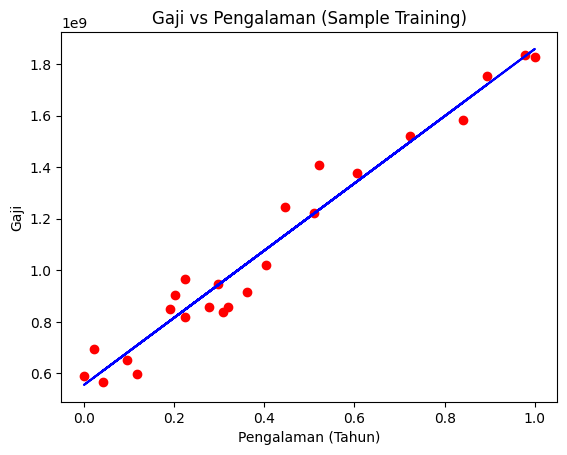

In [16]:
# Visualisasikan sample training
plt.scatter(X_train, y_train, color='red')
plt.plot(X_train, regressor.predict(X_train), color='blue')
plt.title('Gaji vs Pengalaman (Sample Training)')
plt.xlabel('Pengalaman (Tahun)')
plt.ylabel('Gaji')

Text(0, 0.5, 'Gaji')

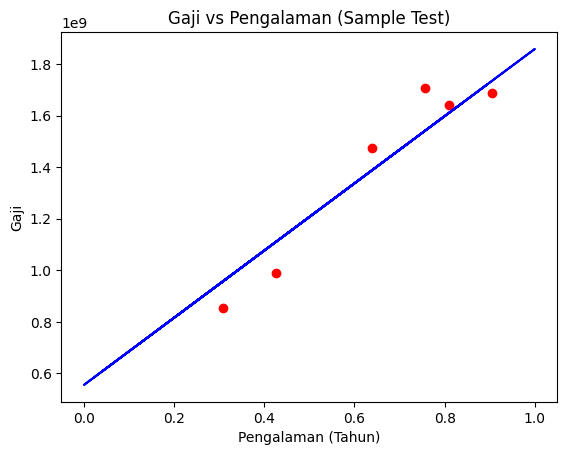

In [17]:
# Visualisasikan sample test
plt.scatter(X_test, y_test, color='red')
plt.plot(X_train, regressor.predict(X_train), color='blue')
plt.title('Gaji vs Pengalaman (Sample Test)')
plt.xlabel('Pengalaman (Tahun)')
plt.ylabel('Gaji')

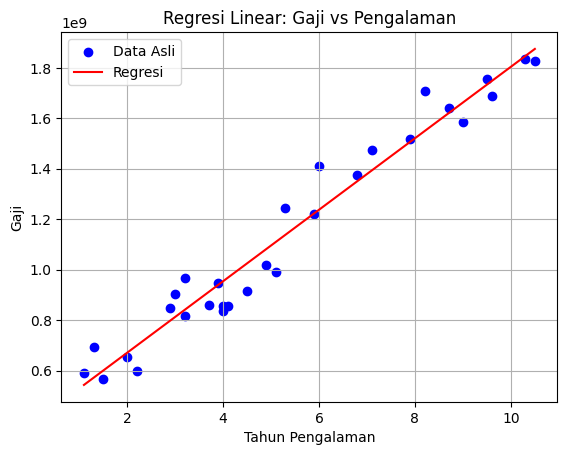

Koefisien (slope): 141749434.82
Intercept: 386883002.98


In [18]:
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# Load data
df_gaji = pd.read_csv('Data_Gaji.csv', sep=';')

# Fitur dan target
X = df_gaji[['Tahun_Pengalaman']]
y = df_gaji['Gaji']

# Model Linear Regression
model_lr = LinearRegression()
model_lr.fit(X, y)

# Prediksi
y_pred = model_lr.predict(X)

# Visualisasi
plt.scatter(X, y, color='blue', label='Data Asli')
plt.plot(X, y_pred, color='red', label='Regresi')
plt.xlabel("Tahun Pengalaman")
plt.ylabel("Gaji")
plt.title("Regresi Linear: Gaji vs Pengalaman")
plt.legend()
plt.grid(True)
plt.show()

print(f"Koefisien (slope): {model_lr.coef_[0]:.2f}")
print(f"Intercept: {model_lr.intercept_:.2f}")
